In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
print(df["gender"].value_counts())

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


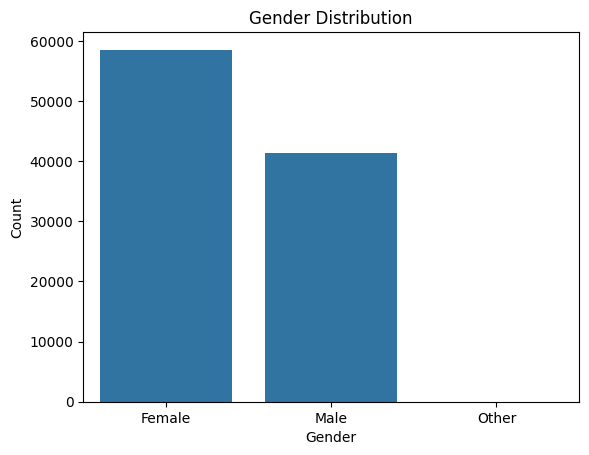

In [7]:
sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [8]:
print(df["smoking_history"].value_counts())

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


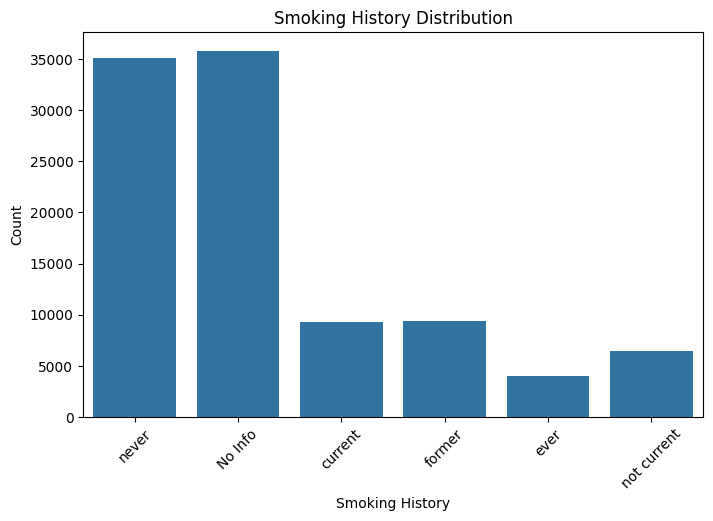

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="smoking_history"
)

plt.title("Smoking History Distribution")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

In [10]:
print(df["diabetes"].value_counts())
print(df["diabetes"].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91500
1     8500
Name: count, dtype: int64


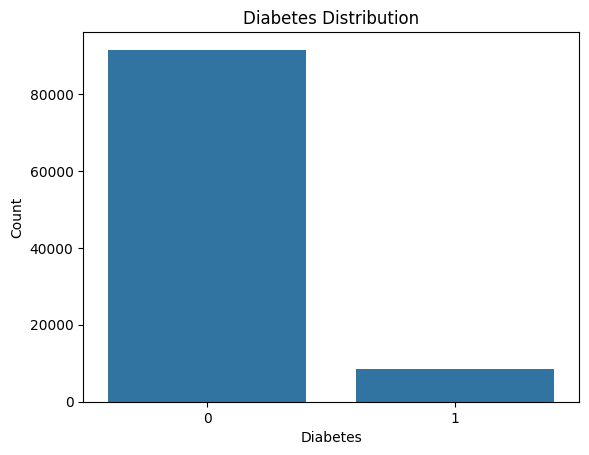

In [11]:
sns.countplot(data=df, x="diabetes")

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

In [12]:
numerical_columns = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

df[numerical_columns].describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


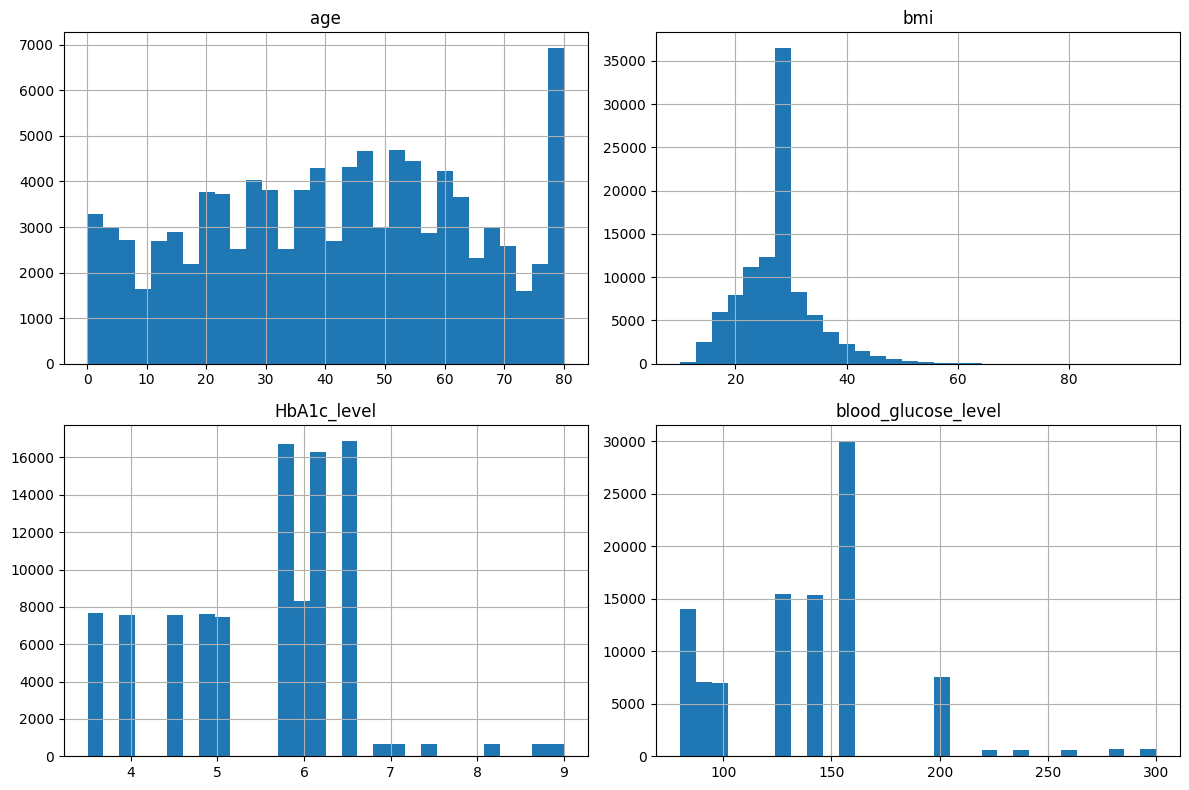

In [13]:
df[numerical_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

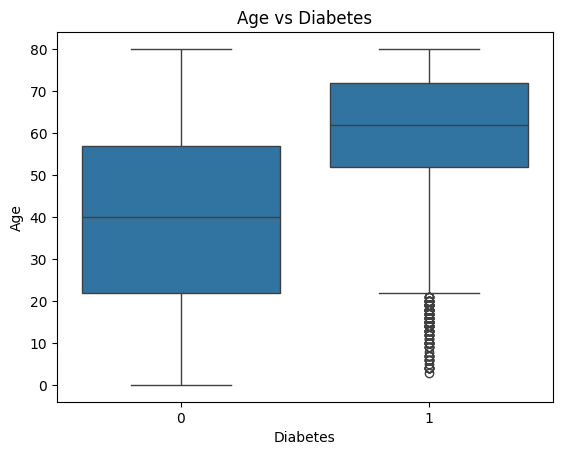

In [14]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="age"
)

plt.title("Age vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Age")

plt.show()

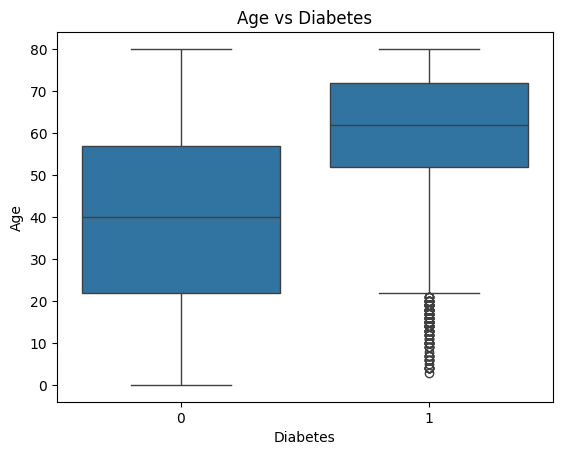

In [15]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="age"
)

plt.title("Age vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Age")

plt.show()

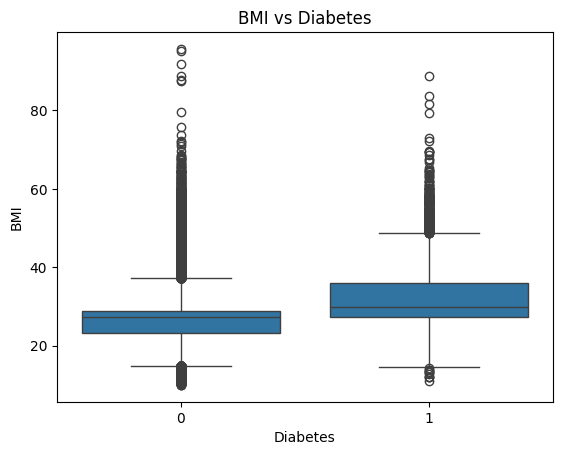

In [16]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="bmi"
)

plt.title("BMI vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("BMI")

plt.show()

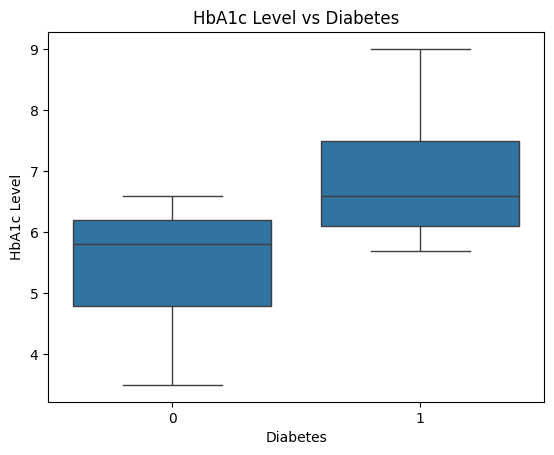

In [17]:
sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level"
)

plt.title("HbA1c Level vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("HbA1c Level")

plt.show()

Correlation matrix


In [18]:
correlation = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "diabetes"
    ]
].corr()

correlation

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


In [19]:
correlation = df[
    [
        "age",
        "hypertension",
        "heart_disease",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "diabetes"
    ]
].corr()

correlation

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


Categorical Features vs Diabetes

In [20]:
gender_diabetes = pd.crosstab(
    df["gender"],
    df["diabetes"],
    normalize="index"
) * 100

print(gender_diabetes)

diabetes           0         1
gender                        
Female     92.381131  7.618869
Male       90.251026  9.748974
Other     100.000000  0.000000


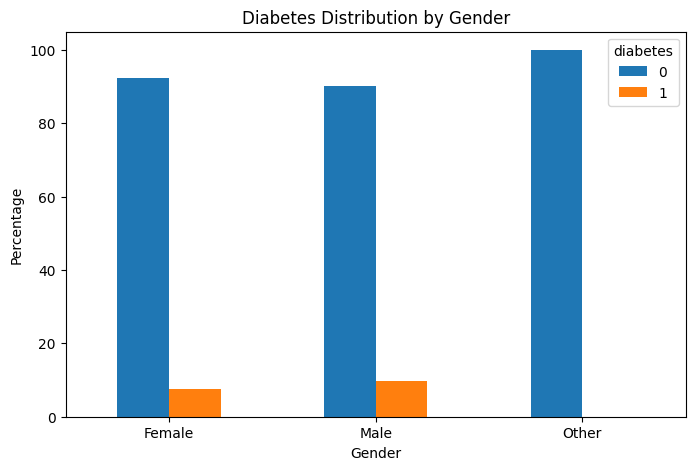

In [21]:
gender_diabetes.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Diabetes Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [22]:
smoking_diabetes = pd.crosstab(
    df["smoking_history"],
    df["diabetes"],
    normalize="index"
) * 100

print(smoking_diabetes)

diabetes                 0          1
smoking_history                      
No Info          95.940362   4.059638
current          89.791083  10.208917
ever             88.211788  11.788212
former           82.998289  17.001711
never            90.465878   9.534122
not current      89.297348  10.702652


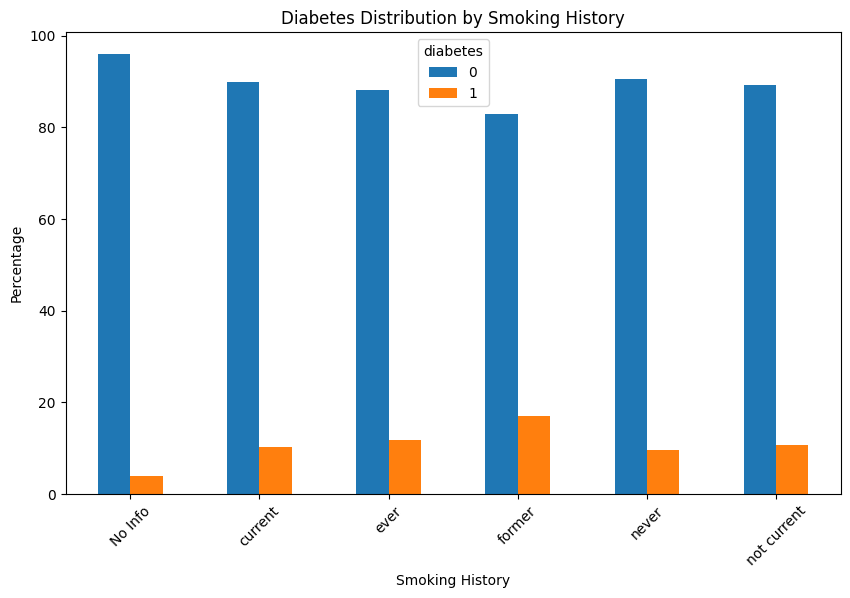

In [23]:
smoking_diabetes.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Diabetes Distribution by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

Remove exact duplicates

In [24]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (100000, 9)
After: (96146, 9)


In [25]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96146, 8)
y shape: (96146,)


In [26]:
categorical_features = [
    "gender",
    "smoking_history"
]

numerical_features = [
    "age",
    "bmi",
    "HbA1c_level",
    "blood_glucose_level"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (76916, 8)
Testing data: (19230, 8)


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [30]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [31]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (76916, 8)
Processed training shape: (76916, 15)
Original testing shape: (19230, 8)
Processed testing shape: (19230, 15)


In [32]:
import joblib

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']